In [1]:
import scvelo as scv
import pandas as pd
import loompy
from matplotlib import rcParams
import matplotlib.pyplot as pl

In [2]:
scv.settings.verbosity = 3  
scv.settings.presenter_view = True  
scv.set_figure_params('scvelo',  dpi_save = 300) 

In [3]:
# https://stackoverflow.com/questions/35668219/how-to-set-up-a-custom-font-with-custom-path-to-matplotlib-global-font00
import matplotlib.font_manager as font_manager

font_dirs = ['/hpc/pmc_stunnenberg/cruiz/scRNA/markers-and-databases/fonts', ]
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)
font_list = font_manager.createFontList(font_files)
font_manager.fontManager.ttflist.extend(font_list)

pl.rcParams['font.family'] = 'Helvetica'

#### Read your data

In [4]:
adata = scv.read('../../../data/blood_ascites/prettx_blood-ascites_myeloid-cells.loom', 
                 cache=True)
adata = scv.utils.merge(adata, ldata)
adata

Variable names are not unique. To make them unique, call `.var_names_make_unique`.


AnnData object with n_obs × n_vars = 7882 × 16282
    obs: 'ClusterID', 'ClusterName', 'SCT_snn_res_0_5', 'nCount_RNA', 'nCount_SCT', 'nFeature_RNA', 'nFeature_SCT', 'orig_ident', 'seurat_clusters', 'sample_batch', 'Clusters', '_X', '_Y', 'initial_size_spliced', 'initial_size_unspliced', 'initial_size'
    var: 'Selected', 'sct_detection_rate', 'sct_gmean', 'sct_residual_mean', 'sct_residual_variance', 'sct_variable', 'sct_variance', 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    obsm: 'mnn_cell_embeddings', 'umap_cell_embeddings'
    layers: 'norm_data', 'scale_data', 'ambiguous', 'matrix', 'spliced', 'unspliced'

In [8]:
import scanpy as sc
sc.pp.neighbors(adata, n_neighbors=200)
sc.tl.paga(adata, groups="celltype")

         Falling back to preprocessing with `sc.pp.pca` and default params.


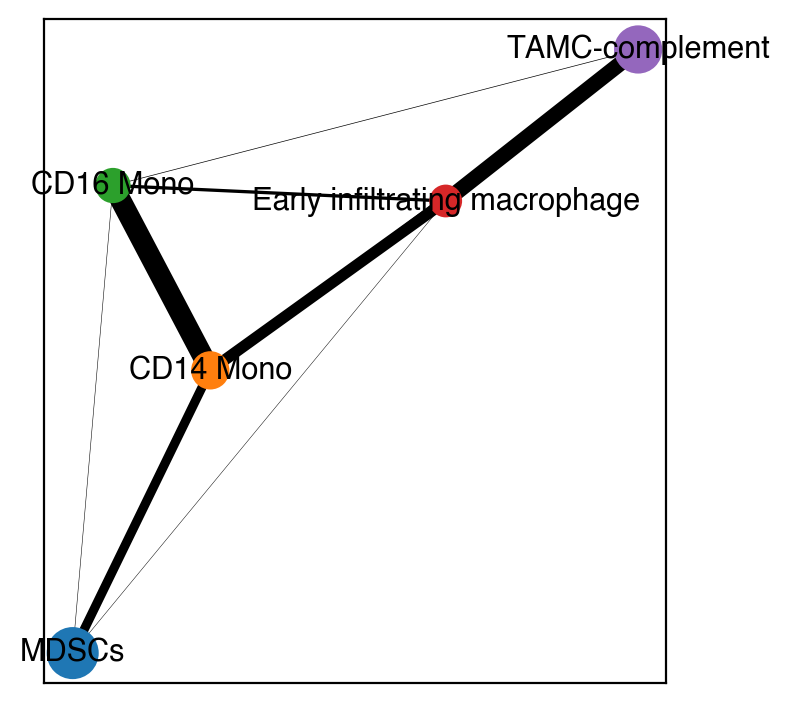

In [9]:
pl.rcParams['figure.figsize'] = (4, 4)  
sc.pl.paga(adata, color=["celltype"], save='paga_blood_ascites.pdf')